In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test, proportional_hazard_test
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index

In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("utkarshx27/breast-cancer-dataset-used-royston-and-altman")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\OLUSOLADE EMMANUEL\.cache\kagglehub\datasets\utkarshx27\breast-cancer-dataset-used-royston-and-altman\versions\1


In [6]:
os.listdir(path)

['gbsg.csv']

In [7]:
data = pd.read_csv(os.path.join(path, 'gbsg.csv'))

In [8]:
data

,Unnamed: 0,pid,age,meno,size,grade,nodes,pgr,er,hormon,rfstime,status
0,1,132,49,0,18,2,2,0,0,0,1838,0
1,2,1575,55,1,20,3,16,0,0,0,403,1
2,3,1140,56,1,40,3,3,0,0,0,1603,0
3,4,769,45,0,25,3,1,0,4,0,177,0
4,5,130,65,1,30,2,5,0,36,1,1855,0
...,...,...,...,...,...,...,...,...,...,...,...,...
681,682,586,51,0,30,3,2,1152,38,1,1760,0
682,683,1273,64,1,26,2,2,1356,1144,1,1152,0
683,684,1525,57,1,35,3,1,1490,209,1,1342,0
684,685,736,44,0,21,2,3,1600,70,0,629,0


In [9]:
data['status'].value_counts()

status
0    387
1    299
Name: count, dtype: int64

In [10]:
data = data.drop('Unnamed: 0', axis=1)

In [11]:
data

,pid,age,meno,size,grade,nodes,pgr,er,hormon,rfstime,status
0,132,49,0,18,2,2,0,0,0,1838,0
1,1575,55,1,20,3,16,0,0,0,403,1
2,1140,56,1,40,3,3,0,0,0,1603,0
3,769,45,0,25,3,1,0,4,0,177,0
4,130,65,1,30,2,5,0,36,1,1855,0
...,...,...,...,...,...,...,...,...,...,...,...
681,586,51,0,30,3,2,1152,38,1,1760,0
682,1273,64,1,26,2,2,1356,1144,1,1152,0
683,1525,57,1,35,3,1,1490,209,1,1342,0
684,736,44,0,21,2,3,1600,70,0,629,0


In [12]:
data.describe()

,pid,age,meno,size,grade,nodes,pgr,er,hormon,rfstime,status
count,686.000000,686.000000,686.000000,686.000000,686.000000,686.000000,686.000000,686.000000,686.000000,686.000000,686.000000
mean,966.061224,53.052478,0.577259,29.329446,2.116618,5.010204,109.995627,96.252187,0.358601,1124.489796,0.435860
std,495.506249,10.120739,0.494355,14.296217,0.582808,5.475483,202.331552,153.083963,0.479940,642.791948,0.496231
min,1.000000,21.000000,0.000000,3.000000,1.000000,1.000000,0.000000,0.000000,0.000000,8.000000,0.000000
25%,580.750000,46.000000,0.000000,20.000000,2.000000,1.000000,7.000000,8.000000,0.000000,567.750000,0.000000
50%,1015.500000,53.000000,1.000000,25.000000,2.000000,3.000000,32.500000,36.000000,0.000000,1084.000000,0.000000
75%,1340.500000,61.000000,1.000000,35.000000,2.000000,7.000000,131.750000,114.000000,1.000000,1684.750000,1.000000
max,1819.000000,80.000000,1.000000,120.000000,3.000000,51.000000,2380.000000,1144.000000,1.000000,2659.000000,1.000000


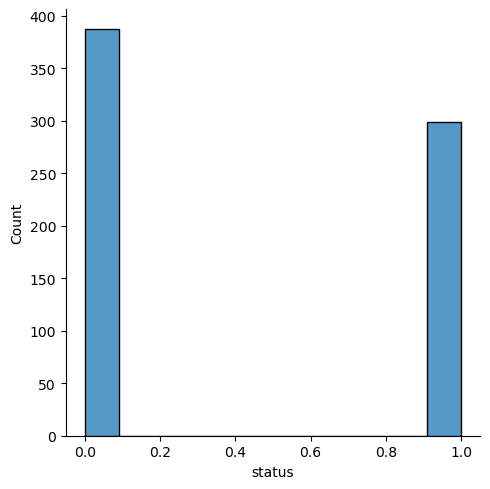

In [13]:
sns.displot(data=data, x='status')

In [14]:
kmf = KaplanMeierFitter()

In [15]:
T = data['rfstime']
E = data['status']

In [16]:
#fit model

In [17]:
kmf.fit(T, event_observed= E)

<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 686 total observations, 387 right-censored observations>

Text(0, 0.5, 'Survival Probability')

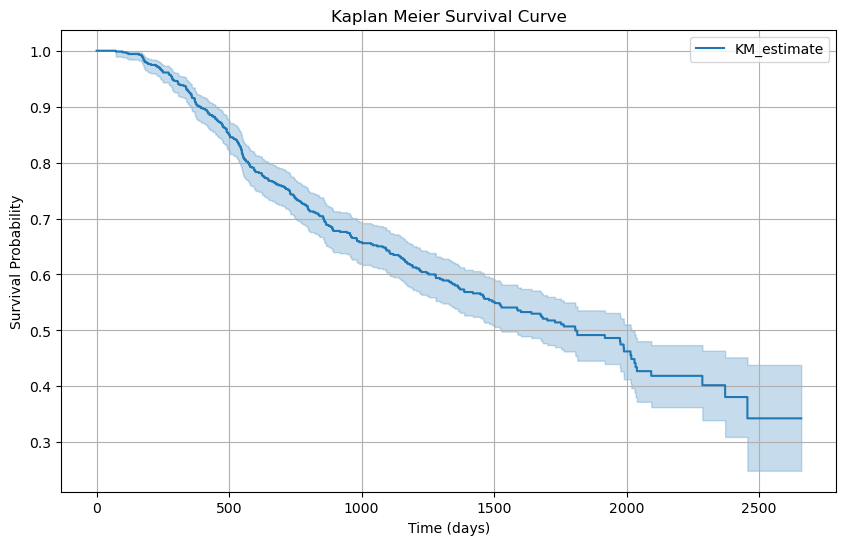

In [18]:
kmf.plot(figsize=(10,6))
plt.grid(True)
plt.title('Kaplan Meier Survival Curve')
plt.xlabel('Time (days)')
plt.ylabel('Survival Probability')

In [19]:
data['status'].value_counts()

status
0    387
1    299
Name: count, dtype: int64

In [20]:
print('Median Survival Time is', kmf.median_survival_time_, 'days')

Median Survival Time is 1807.0 days


In [21]:
kmf.confidence_interval_

,KM_estimate_lower_0.95,KM_estimate_upper_0.95
0.0,1.000000,1.000000
8.0,1.000000,1.000000
15.0,1.000000,1.000000
16.0,1.000000,1.000000
17.0,1.000000,1.000000
...,...,...
2551.0,0.249125,0.438274
2556.0,0.249125,0.438274
2563.0,0.249125,0.438274
2612.0,0.249125,0.438274


In [22]:
#Group Classification using the Tumor Grade

Text(0, 0.5, 'Survival Probability')

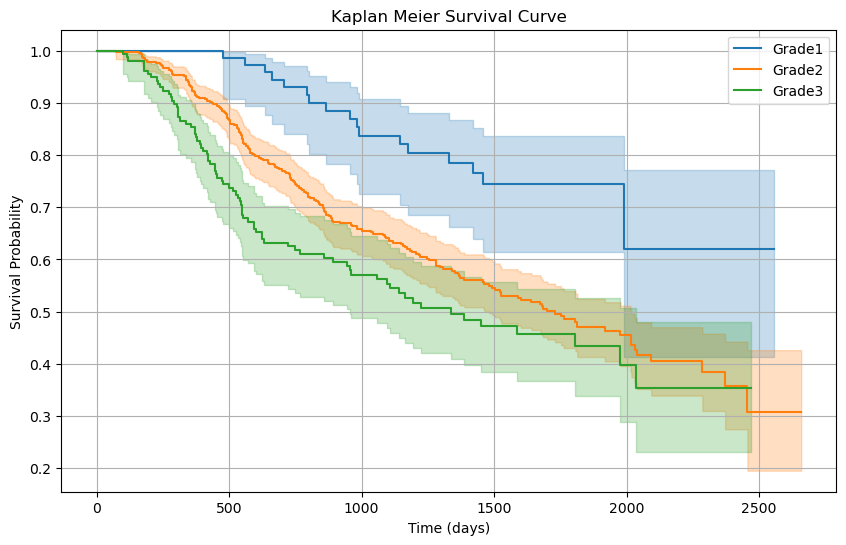

In [23]:
for grade in sorted(data['grade'].unique()):
    mask = data['grade'] == grade
    kmf.fit(data['rfstime'][mask], event_observed= data['status'][mask], label=f"Grade{grade}")
    kmf.plot_survival_function(figsize=(10,6))

plt.grid(True)
plt.title('Kaplan Meier Survival Curve')
plt.xlabel('Time (days)')
plt.ylabel('Survival Probability')

In [24]:
#Log Rank Test

In [25]:
results = multivariate_logrank_test(data['rfstime'], data['grade'], data['status'])
results.print_summary()

<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 2
         test_name = multivariate_logrank_test

---
 test_statistic      p  -log2(p)
          21.09 <0.005     15.22

In [26]:
#COX Model

In [27]:
cox = CoxPHFitter()

In [28]:
cols = ['age', 'meno', 'size', 'grade', 'pgr', 'er', 'hormon', 'rfstime', 'status']

In [29]:
data_for_cox = data[cols]

In [30]:
cox.fit(data_for_cox, duration_col='rfstime', event_col='status')

<lifelines.CoxPHFitter: fitted with 686 total observations, 387 right-censored observations>

In [31]:
cox.print_summary()

<lifelines.CoxPHFitter: fitted with 686 total observations, 387 right-censored observations>
             duration col = 'rfstime'
                event col = 'status'
      baseline estimation = breslow
   number of observations = 686
number of events observed = 299
   partial log-likelihood = -1753.90
         time fit was run = 2025-12-11 17:31:43 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
age       -0.01      0.99      0.01           -0.03            0.01                0.97                1.01
meno       0.28      1.32      0.18           -0.08            0.64                0.92                1.89
size       0.02      1.02      0.00            0.01            0.02                1.01                1.02
grade      0.28      1.32      0.11            0.07            0.48                1.08                1.62
pgr       -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
er         0.00      1.00      0.00           -0.00            0.00                1.00                1.00
hormon    -0.34      0.71      0.13           -0.60           -0.09                0.55                0.91

           cmp to     z      p  -log2(p)
covariate                               
age          0.00 -0.94   0.35      1.53
meno         0.00  1.50   0.13      2.92
size         0.00  4.14 <0.005     14.83
grade        0.00  2.65   0.01      6.95
pgr          0.00 -4.02 <0.005     14.05
er           0.00  0.36   0.72      0.48
hormon       0.00 -2.65   0.01      6.96
---
Concordance = 0.65
Partial AIC = 3521.81
log-likelihood ratio test = 68.40 on 7 df
-log2(p) of ll-ratio test = 38.23

In [32]:
#Check Proportional Hazard Assumption

In [33]:
dataa = data.drop(['pid','nodes'], axis=1)

In [34]:
pht_result = proportional_hazard_test(cox, dataa, time_variable='rfstime', event_variable='status')

In [35]:
pht_result.print_summary()

<lifelines.StatisticalResult: proportional_hazard_test>
    time_transform = rank
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 686 total observations, 387 right-censored observations>
     time_variable = rfstime
    event_variable = status
         test_name = proportional_hazard_test

---
        test_statistic    p  -log2(p)
age               2.23 0.14      2.89
er                0.88 0.35      1.52
grade             5.61 0.02      5.81
hormon            0.17 0.68      0.55
meno              0.08 0.77      0.37
pgr               1.57 0.21      2.25
size              0.35 0.56      0.85

In [36]:
#Adjusting Survival Curve

In [37]:
mean_values = dataa.drop(['rfstime', 'status'], axis=1).mean()

In [38]:
mean_values

age        53.052478
meno        0.577259
size       29.329446
grade       2.116618
pgr       109.995627
er         96.252187
hormon      0.358601
dtype: float64

In [39]:
grade1 = mean_values.copy()
grade3 = mean_values.copy()

In [40]:
grade1['grade']=1
grade3['grade']=3

In [41]:
surv_grade1 = cox.predict_survival_function(grade1.to_frame().T)
surv_grade3 = cox.predict_survival_function(grade3.to_frame().T)

Text(0.5, 1.0, 'Adjusted Survival Curves by Tumor Grade')

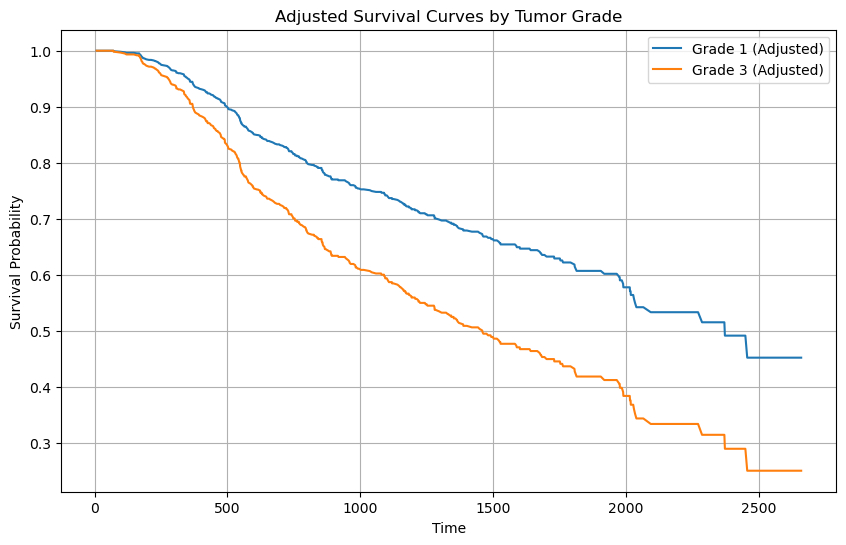

In [42]:
plt.figure(figsize=(10,6))
plt.plot(surv_grade1.index, surv_grade1.values, label='Grade 1 (Adjusted)')
plt.plot(surv_grade3.index, surv_grade3.values, label='Grade 3 (Adjusted)')

plt.legend()
plt.grid(True)
plt.xlabel('Time')
plt.ylabel('Survival Probability')
plt.title('Adjusted Survival Curves by Tumor Grade')

In [43]:
#Validate the cox model (Model Performance)

In [44]:
#Concordance Index(C-Index)

In [45]:
c_index = concordance_index(dataa['rfstime'], -cox.predict_partial_hazard(dataa), dataa['status'])
c_index

np.float64(0.6506177107129975)


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.



<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 686 total observations, 387 right-censored observations>
         test_name = proportional_hazard_test

---
             test_statistic    p  -log2(p)
age    km              2.34 0.13      2.99
       rank            2.23 0.14      2.89
er     km              0.60 0.44      1.18
       rank            0.88 0.35      1.52
grade  km              4.39 0.04      4.79
       rank            5.61 0.02      5.81
hormon km              0.16 0.68      0.55
       rank            0.17 0.68      0.55
meno   km              0.06 0.80      0.32
       rank            0.08 0.77      0.37
pgr    km              1.68 0.19      2.36
       rank            1.57 0.21      2.25
size   km              0.34 0.56      0.84
       rank            0.35 0.56      0.85



1. Variable 'grade' failed the non-proportional test: p-value is 0.0179.

   Advice: with so few unique values (only 3), you can include `strata=['grade', ...]` in the call
in `.fit`. See documentation in link [E] below.

   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Introduce-time-varying-covariates
[D]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Modify-the-functional-form
[E]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20ass

[[<Axes: xlabel='rank-transformed time\n(p=0.1352)'>,
  <Axes: xlabel='km-transformed time\n(p=0.1262)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.7730)'>,
  <Axes: xlabel='km-transformed time\n(p=0.8032)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.5566)'>,
  <Axes: xlabel='km-transformed time\n(p=0.5591)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0179)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0361)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.2107)'>,
  <Axes: xlabel='km-transformed time\n(p=0.1949)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.3486)'>,
  <Axes: xlabel='km-transformed time\n(p=0.4401)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.6814)'>,
  <Axes: xlabel='km-transformed time\n(p=0.6850)'>]]

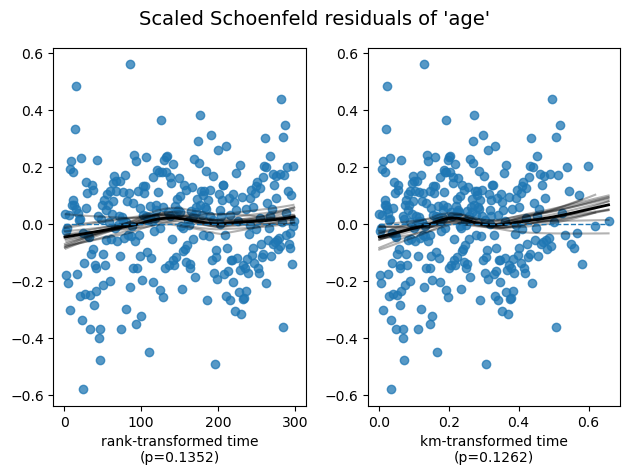

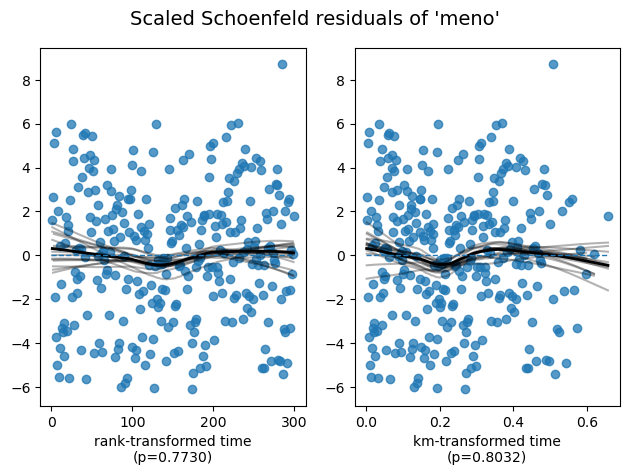

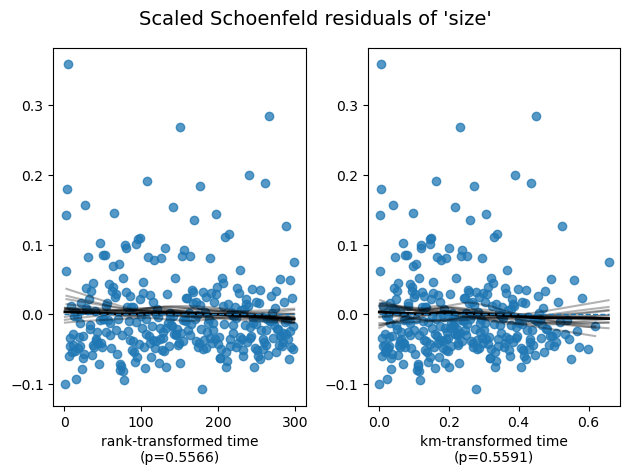

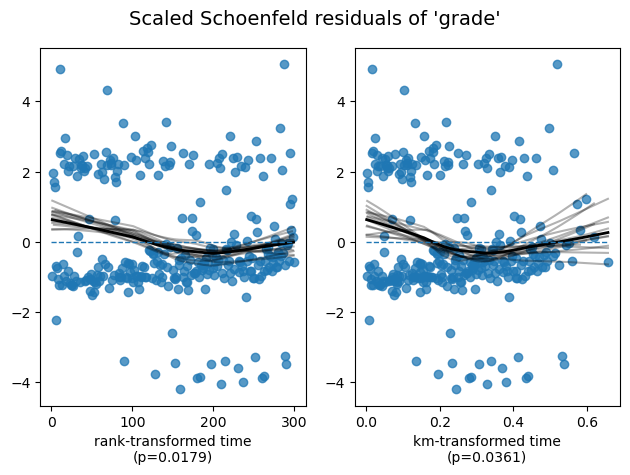

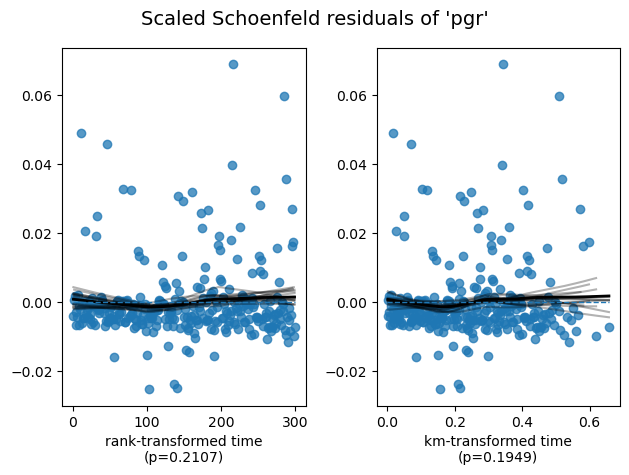

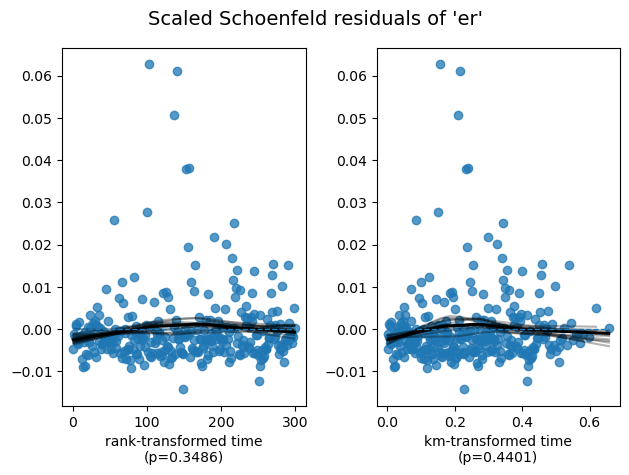

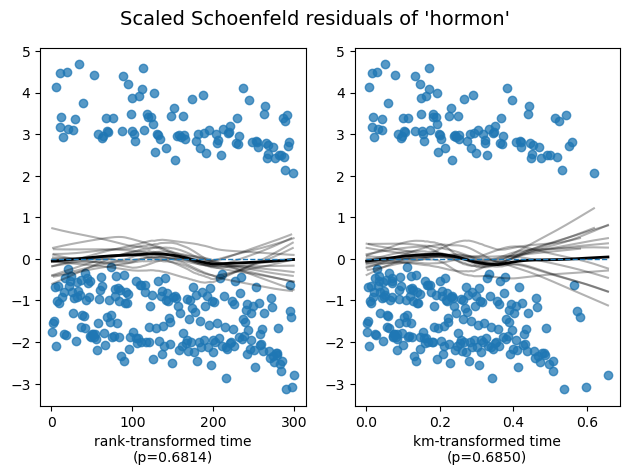

In [46]:
#Check Residual Diagnostics
cox.check_assumptions(dataa, p_value_threshold=0.05, show_plots=True)

In [47]:
#Identify Outliers
residuals = cox.compute_residuals(dataa, kind='deviance')
residuals.describe()

,rfstime,deviance
count,686.000000,686.000000
mean,1124.489796,-0.035278
std,642.791948,1.152672
min,8.000000,-1.968295
25%,567.750000,-0.989255
50%,1084.000000,-0.461506
75%,1684.750000,0.983098
max,2659.000000,3.340691


In [48]:
data['status'].value_counts()

status
0    387
1    299
Name: count, dtype: int64